In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
from matplotlib.ticker import MultipleLocator, AutoLocator, AutoMinorLocator
plt.style.use('default')

In [7]:
# Constantes
G = 6.67430e-11  # m³/(kg·s²)
c = 2.99792458e8  # m/s
M_sun = 1.989e30  # kg
R_sun = 6.96e8    # m

In [8]:
def schwarzschild_radius(M):
    """r_s = 2GM/c2"""
    return 2 * G * M / c**2

Pour certaines étoiles trop massives ou pour certains systèmes binaires où une étoile à neutrons accrète trop, la masse de Chandrasekhar est dépassée et la compacité maximale est dépassée. L'objet s'effondre alors sur lui-même. Nous proposons un aperçu léger d'une modélisation de ce phénomène suite au système T.O.V..


## II -Etude de la dynamique de la surface--chute libre





Étudions dans un premier temps la dynamique de la surface. À la surface, comme la masse contenue par-dessous est constante et que l'on suppose le vide à l'extérieur, on a simplement à étudier une chute libre. On suit encore une métrique de Schwarzschild grâce au théorème de Birkhoff.
$$ ds^2 = -\left(1 - \frac{2GM}{rc^2}\right)c^2dt^2 + \left(1 - \frac{2GM}{rc^2}\right)^{-1}dr^2 + r^2d\Omega^2 $$


Nous allons dans cette partie étudier cette chute libre sous différents aspects. Nous allons essayer de définir un système de coordonnées adapté mais également obtenir des informations physiques sur ce que perçoivent les observateurs tant bien à la surface qu'à l'infini.







### Equations générales

Considérons un point matériel à la surface de l'objet stellaire. On se dote du lagrangien correspondant: $\mathcal{L}=\sqrt{-g_{\mu\nu}u^{\mu}u^{\nu}}$ que l'on paramètrise par $\tau$ par convenance. On a donc ààààààààà$\mathcal{L}=\sqrt{\frac{d^2s}{d\lambda^2}}=c$. En y injectant la métrique de Schwarzschild :
$$\mathcal{L} = \sqrt{\left(1 - \frac{R_s}{r}\right)c^2\dot{t}^2 - \left(1 - \frac{R_s}{r}\right)^{-1}\dot{r}^2 - r^2\frac{d\Omega^2}{d\lambda^2}}$$


On se ramène au cas $\theta = \phi=0$ par changement de coordonnées, on obtient :


$$\frac{d}{d\lambda}\left(\frac{\partial \mathcal{L}}{\partial \dot{x}^\mu}\right) = \frac{\partial \mathcal{L}}{\partial x^\mu} \implies
\begin{cases}
\frac{1}{2}\left(\frac{dr}{d\lambda}\right)^2 + V(r) = \frac{1}{2}\left(\frac{\epsilon^2}{c^2} - c^2\right) \\
V(r) = -\frac{GM}{r} + \frac{l^2}{2r^2} - \frac{GMl^2}{r^3c^2}
\end{cases}$$


où $\epsilon$ et $l$ sont des constantes du mouvement données par :
$$\begin{cases}
l = r^2\dot{\phi} \\
\frac{\epsilon}{c^2} = \left(1 - \frac{R_s}{r}\right)\dot{t}
\end{cases}$$





### Cas $l=0$ et $u^r_0=0$

Comme à l'instant initial on suppose la surface sans rotation par hypothèse et au repos (échelles de temps de la chute libre très petites devant celles des autres phénomènes la précédant), on peut légitimement poser $l = v_0^\phi = 0$ , on a alors $e = c^2 \sqrt{1 - \frac{R_s}{r_0}}$.  
Après manipulations, cela donne:


$$
\begin{cases}
\frac{dr}{d\tau} = -c \sqrt{\frac{R_s}{r} - \frac{R_s}{r_0}} & (1) \\
\frac{dt}{d\tau} = \frac{\sqrt{1 - \frac{R_s}{r_0}}}{1 - \frac{R_s}{r}} & (2)
\end{cases}
$$


On intègre $(1)$ en posant $\tau(0) = 0$ :


$$c\tau = -\int_{r_0}^{r} \frac{dr}{\sqrt{\frac{R_s}{r} - \frac{R_s}{r_0}}}$$


En posant :
$\begin{cases} r = r_0 \sin^2 \theta \\ dr = 2r_0 \cos \theta \sin \theta \, d\theta \end{cases}$


$$c\tau = -2r_0 \sqrt{\frac{r_0}{R_s}} \int_{\arcsin \sqrt{\frac{r}{r_0}}}^{\pi/2} \sin^2 \theta \, d\theta$$


D'où :


$$\tau = \frac{1}{c} r_0 \sqrt{\frac{r_0}{R_s}} \left[ \arccos \sqrt{\frac{r}{r_0}} + \sqrt{\frac{r}{r_0}} \sqrt{1 - \frac{r}{r_0}} \right] \quad (3)$$





Pour avoir l'allure de cette solution, traçons la :
    On définit la fonction
`ff_proper_time`


In [9]:
def ff_proper_time(r0, r, M):
    """tau = r0/c * sqrt(r0/r_s)[pi/2 - arcsin(sqrt(r/r0))+sqrt(r/r0)*sqrt(1-r/r0)]"""
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    # Protéger contre les valeurs invalides
    x = np.clip(r / r0, 0, 1)  # Garder 0 <= r/r0 <= 1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        result = r0 / c * np.sqrt(r0/r_s) * (np.pi/2 - np.arcsin(x) + x * np.sqrt(1 - x**2))
    
    return result

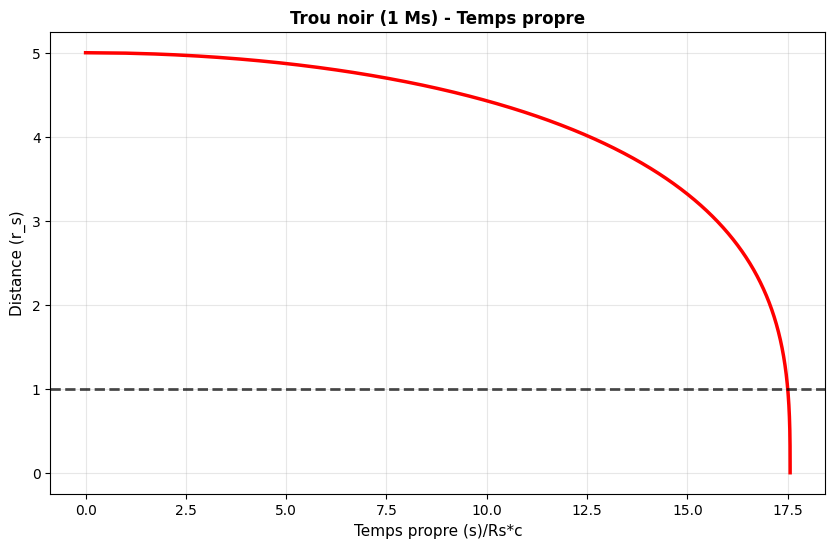

In [10]:
# Tracé du temps propre pour un trou noir de 1 masse solaire

fig ,ax = plt.subplots(figsize=(10, 6))
M_bh = M_sun
r_s = schwarzschild_radius(M_bh)
r_bh = np.linspace(5*r_s, r_s*0.001, 1000)  # Decroissant de 5*r_s a r_s
tau_bh = ff_proper_time(5*r_s, r_bh, M_bh)
ax.plot(tau_bh/r_s*c, r_bh/r_s, 'r-', linewidth=2.5)
ax.axhline(1, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Temps propre (s)/Rs*c', fontsize=11)
ax.set_ylabel('Distance (r_s)', fontsize=11)
ax.set_title('Trou noir (1 Ms) - Temps propre', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

On voit que l'observateur rentre bien dans une zone où $r<R_s$ et sa chute s'accélère de façon très importante et se passe dans un temps fini. Mais, n'oublions pas notre objectif : nous voulons aussi connaitre $t(r)$ pour savoir ce que perçoit un observateur à l'infini, par exemple.


On a toujours l'équation implicite :  $$ \frac{dt}{d\tau} = \frac{\sqrt{1 - \frac{R_s}{r_0}}}{1 - \frac{R_s}{r}}$$
Si son intégration peut paraître alléchante, où l'on procède de manière similaire à ce que l'on fait pour $\tau$, il est préférable de procéder par integration numérique :


On définit la fonction `ff_coordinate_time`





In [11]:
def ff_cordinate_time(r0, r, M):
    """
    Calcul du temps coordonné par intégration numérique.
    r décroît de r0 vers r_s
    dt/dr = sqrt(1-r_s/r0) / (1-r_s/r) * (-1/(c*sqrt(r_s/r - r_s/r0)))
    """
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    # Vérification: r0 doit être > r_s
    if r0 <= r_s:
        raise ValueError(f"r0 ({r0}) doit être > r_s ({r_s})")
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # r_s/r - r_s/r0 > 0 quand r < r0 (descente)
        sqrt_arg = r_s / r - r_s / r0
        sqrt_arg = np.clip(sqrt_arg, 1e-10, None)
        
        # dt/dr négatif (r décroît)
        dt_dr = np.sqrt(1 - r_s/r0) / (1 - r_s/r) * (-1) / (c * np.sqrt(sqrt_arg))
        
        # Intégration (valeur absolue pour temps positif)
        dr = np.gradient(r)
        t_coord = np.cumsum((dt_dr * dr))
        t_coord = t_coord - t_coord[0]
    
    return t_coord


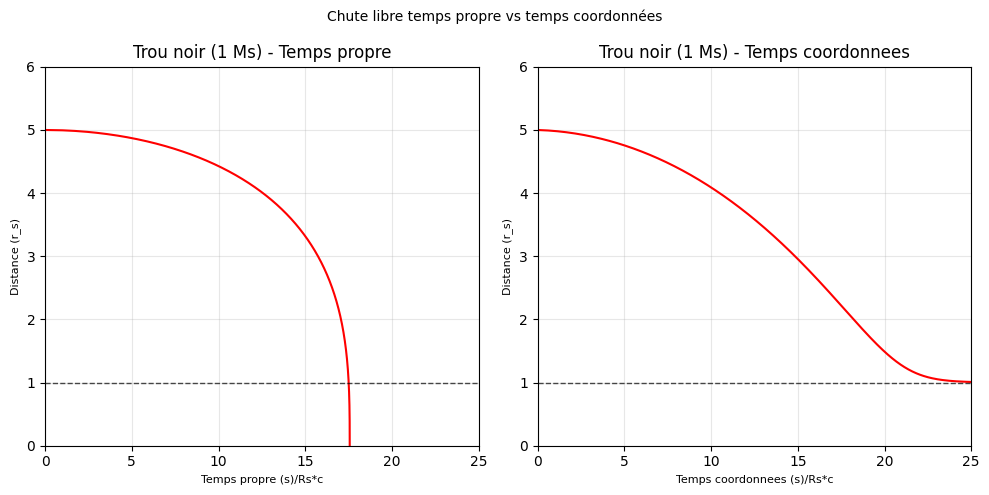

In [12]:
# Tracé du temps coordonné pour un trou noir de 1 masse solaire et comparaison avec le temps propre
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Chute libre temps propre vs temps coordonnées', fontsize=10)

# Trou noir 1 M☉ - proper time
ax = axes[0]
M_bh = M_sun
r_s = schwarzschild_radius(M_bh)
r_bh = np.linspace(5*r_s, r_s*0.001, 1000)  
tau_bh = ff_proper_time(5*r_s, r_bh, M_bh)
ax.plot(tau_bh/r_s*c, r_bh/r_s, 'r-', linewidth=1.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Temps propre (s)/Rs*c', fontsize=8)
ax.set_ylabel('Distance (r_s)', fontsize=8)
ax.set_title('Trou noir (1 Ms) - Temps propre')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 25)
ax.set_ylim(0, 6)


# Trou noir 1 M☉ - coordinate time
ax = axes[1]
M_bh = M_sun
r_s = schwarzschild_radius(M_bh)
r_bh = np.linspace(5*r_s, r_s, 1000)  
t_coord = ff_cordinate_time(5*r_s, r_bh, M_bh)
ax.plot(t_coord/r_s*c, r_bh/r_s, 'r-', linewidth=1.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Temps coordonnees (s)/Rs*c', fontsize=8)
ax.set_ylabel('Distance (r_s)', fontsize=8)
ax.set_title('Trou noir (1 Ms) - Temps coordonnees')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 25)
ax.set_ylim(0, 6)


plt.tight_layout()
plt.show()

On voit que pour l'observateur à l'infini l'étoile semble ralentir et s'arrêter lorsqu'elle atteint le rayon critique de Schwarzschild.


Une fois ces résultats préliminaires établis, on aperçoit que pour décrire de manière générale la chute libre de la surface dans un système de coordonnées plus général que le temps propre, les coordonnées classiques amènent à des cas pathologiques. Traçons les géodésiques pour s'en rendre compte encore mieux. D'un point de vue naïf, on s'attend à ce que la lumière puisse "s'échapper" que lorsque $r>R_s$ et qu'un photon plongeant dans le trou noir le pénètre réellement.





### Geodesiques

Traçons donc les cônes de lumière dans les coordonnées classiques qui sont définies par $ds^2=0$ ou :
$$\frac{1}{c}\frac{dr}{dt}=\pm\left|1-\frac{R_s}{r}\right|$$


Cela amène techniquement à quatre solutions que l'on divise comme suit :


$r>R_s$ : $$r-r_0+R_s \ln{\frac{r-R_s}{r_0-R_s}}=c(t-t_0) \quad \text{et} \quad r-r_0-R_s \ln{\frac{r-R_s}{r_0-R_s}}=c(t-t_0)$$


$r<R_s$ : $$r-r_0-R_s \ln{\frac{R_s-r}{R_s-r_0}}=c(t-t_0) \quad \text{et} \quad r-r_0+R_s \ln{\frac{R_s-r}{R_s-r_0}}=c(t-t_0)$$


Ces équations définissent les parties rentrantes et sortantes de nos cônes de lumière pour les deux différentes situations. Implémentons cela avec les fonctions `schwarzschild_geo _p(m)` et `schwarzschild_geo _p(m)inf`:





In [13]:
# Géodésiques nulles (lumière) dans le champ de Schwarzschild

def schwarzchild_geo_p(t0,r0, r, M):
    """Géodésique nulle sortantes: t augmente quand r augmente"""

    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    t = t0+ (r-r0) / c + r_s/c*np.log((r-r_s)/(r0-r_s))
    return t

def schwarzchild_geo_m(t0,r0, r, M):
    """Géodésique nulle entrante: t augmente quand r diminue"""

    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    
    t = t0 + (r0 - r) / c - r_s/c*np.log(np.abs((r-r_s)/(r0-r_s)))
    return t

def schwarzchild_geo_p_inf(t0,r0, r, M):
    """Géodésique nulle sortantes: t augmente quand r augmente"""

    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    t = t0+ (r0-r) / c + r_s/c*np.log((r_s-r)/(-r0+r_s))
    return t

def schwarzchild_geo_m_inf(t0,r0, r, M):
    """Géodésique nulle entrante: t augmente quand r diminue"""
    
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    
    t = t0 + (r - r0) / c - r_s/c*np.log(np.abs((r_s-r)/(-r0+r_s)))
    return t

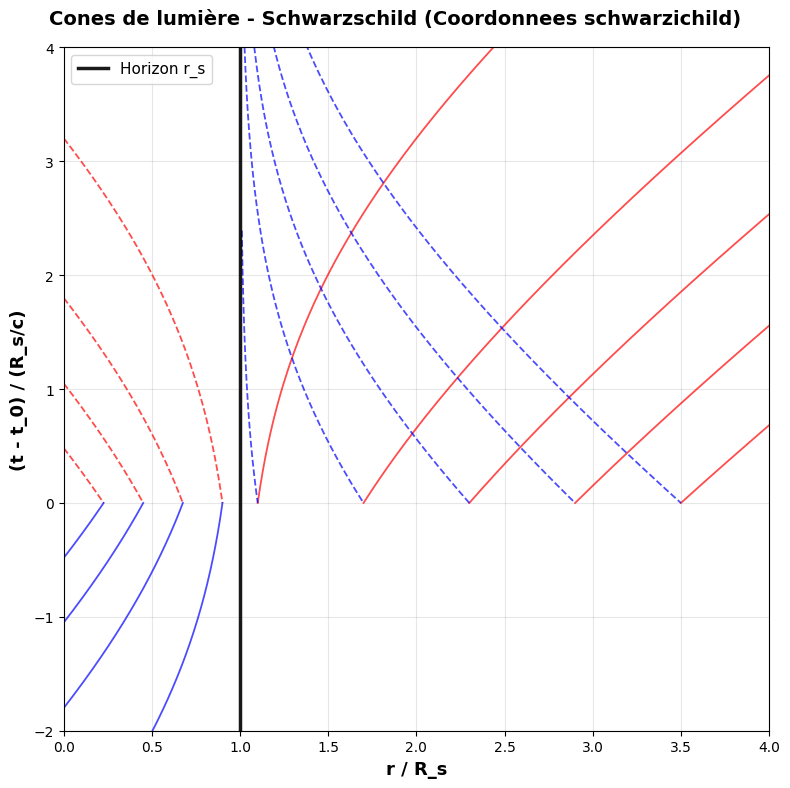

In [14]:
fig, axe = plt.subplots(figsize=(8, 8))
fig.suptitle('Cones de lumière - Schwarzschild (Coordonnees schwarzichild)', fontsize=14, fontweight='bold')

M_bh = M_sun
r_s = schwarzschild_radius(M_bh)

# Points de départ (r0, t0) décalés - pour avoir l'effet ondulant
r0_values = np.linspace(1.1*r_s, 3.5*r_s, 5)
t0 = 0
for r0 in r0_values:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace(r0, 4*r_s, 200)
    t_out = schwarzchild_geo_p(t0, r0, r_out, M_bh)
    axe.plot(r_out/r_s, t_out/(r_s/c), 'r-', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(1.01*r_s, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = schwarzchild_geo_m(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    axe.plot(r_in/r_s, t_in/(r_s/c), 'b--', linewidth=1.3, alpha=0.7)

r0_values_inf = np.linspace(0.001*r_s, 0.9*r_s, 5)

for r0 in r0_values_inf:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace( 0,r0, 200)
    t_out = schwarzchild_geo_p_inf(t0, r0, r_out, M_bh)
    axe.plot(r_out/r_s, t_out/(r_s/c), 'r--', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(0, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = schwarzchild_geo_m_inf(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    axe.plot(r_in/r_s, t_in/(r_s/c), 'b-', linewidth=1.3, alpha=0.7)

# Horizon des événements
axe.axvline(1, color='black', linestyle='-', linewidth=2.5, alpha=0.9, label='Horizon r_s')


axe.set_xlabel('r / R_s', fontsize=13, fontweight='bold')
axe.set_ylabel('(t - t_0) / (R_s/c)', fontsize=13, fontweight='bold')
axe.set_xlim(0, 4)
axe.set_ylim(-2, 4)
axe.grid(True, alpha=0.3)
axe.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

On voit que ces coordonnées ne sont pas adaptées pour décrire la géodésique entrante, car t diverge quand r approche r_s. C'est un artefact de la coordonnée t, pas une singularité physique. On introduit alors un autre système qui retranscrira mieux ce qui a été évoqué plus tôt : les coordonnées d'Eddington-Finkelstein.


Pour cela on définit $\tilde{t}=t+\frac{R_S}{c}\ln\left|\frac{r}{R_S}-1\right|$. Le terme, une fois différencié, compensera les divergences en $r\to R_S$ Cette nouvelle coordonnée apporte aussi des termes croisés tels que la métrique s'écrit dorénavant :  $$ds^2 = -\left(1-\frac{R_S}{r}\right)d\tilde{t}^2 + 2\left(1-\frac{R_S}{r}\right)d\tilde{t}dr + \left(1+\frac{R_S}{r}\right)dr^2 +r^2 d\Omega^2$$


Traçons les géodésiques dans ce nouveau système de coordonnées pour vérifier que nous avons bien des géodésiques entrantes qui ne divergent pas en $r\to R_S$ :





In [15]:
def ef_geo_p(t0,r0, r, M):
   
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    t= t0+ (r-r0) / c + 2*r_s/c*np.log((r-r_s)/(r0-r_s))    
    return t

def ef_geo_m(t0,r0, r, M):
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    t= t0+ (r0-r) / c 
    return t


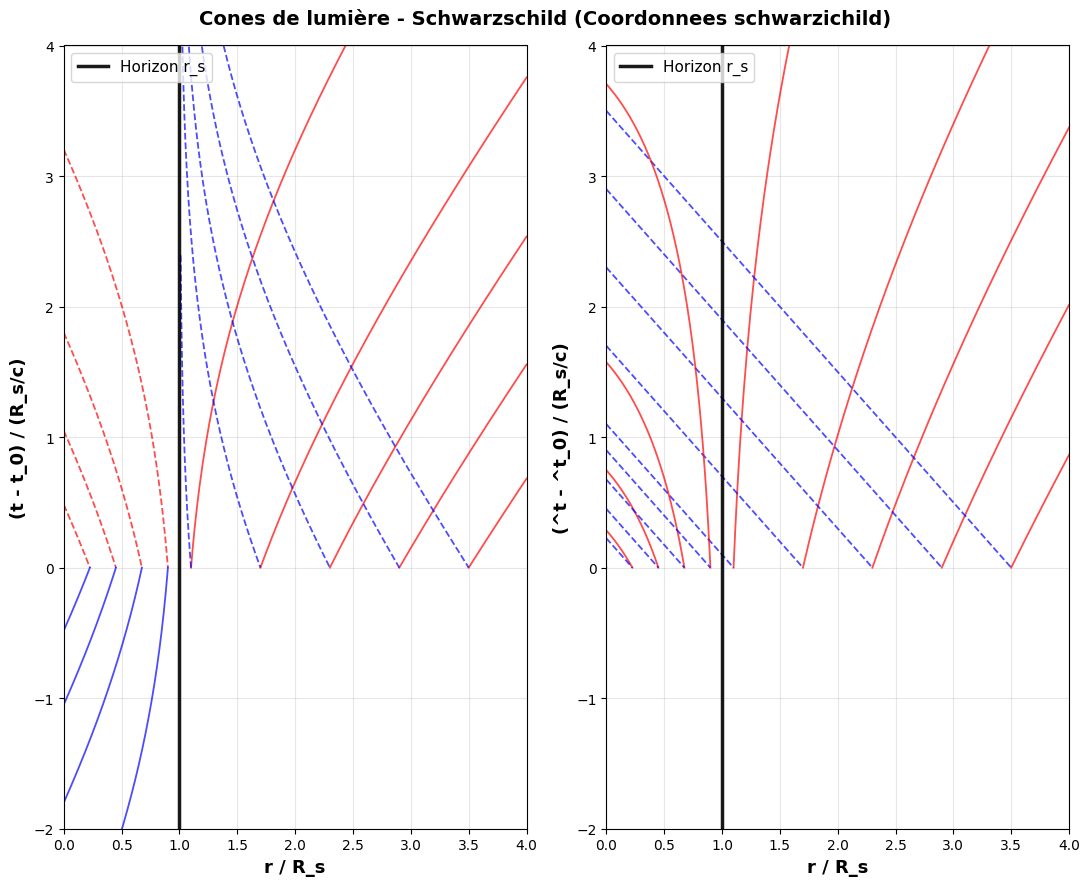

In [16]:


fig, ax = plt.subplots(1,2,figsize=(11, 9))
fig.suptitle('Cones de lumière - Schwarzschild (Coordonnees schwarzichild)', fontsize=14, fontweight='bold')

M_bh = M_sun
r_s = schwarzschild_radius(M_bh)

# Points de départ (r0, t0) décalés - pour avoir l'effet ondulant
r0_values = np.linspace(1.1*r_s, 3.5*r_s, 5)
t0 = 0
axe=ax[0]
for r0 in r0_values:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace(r0, 4*r_s, 200)
    t_out = schwarzchild_geo_p(t0, r0, r_out, M_bh)
    axe.plot(r_out/r_s, t_out/(r_s/c), 'r-', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(1.01*r_s, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = schwarzchild_geo_m(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    axe.plot(r_in/r_s, t_in/(r_s/c), 'b--', linewidth=1.3, alpha=0.7)

r0_values_inf = np.linspace(0.001*r_s, 0.9*r_s, 5)

for r0 in r0_values_inf:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace( 0,r0, 200)
    t_out = schwarzchild_geo_p_inf(t0, r0, r_out, M_bh)
    axe.plot(r_out/r_s, t_out/(r_s/c), 'r--', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(0, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = schwarzchild_geo_m_inf(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    axe.plot(r_in/r_s, t_in/(r_s/c), 'b-', linewidth=1.3, alpha=0.7)

# Horizon des événements
axe.axvline(1, color='black', linestyle='-', linewidth=2.5, alpha=0.9, label='Horizon r_s')


axe.set_xlabel('r / R_s', fontsize=13, fontweight='bold')
axe.set_ylabel('(t - t_0) / (R_s/c)', fontsize=13, fontweight='bold')
axe.set_xlim(0, 4)
axe.set_ylim(-2, 4)
axe.grid(True, alpha=0.3)
axe.legend(fontsize=11, loc='upper left')

ax2=ax[1]
for r0 in r0_values:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace(r0, 4*r_s, 200)
    t_out = ef_geo_p(t0, r0, r_out, M_bh)
    ax2.plot(r_out/r_s, t_out/(r_s/c), 'r-', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(0, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = ef_geo_m(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    ax2.plot(r_in/r_s, t_in/(r_s/c), 'b--', linewidth=1.3, alpha=0.7)

for r0 in r0_values_inf:
    # Géodésiques sortantes (vont vers l'extérieur)
    r_out = np.linspace( 0,r0, 200)
    t_out = ef_geo_p(t0, r0, r_out, M_bh)
    ax2.plot(r_out/r_s, t_out/(r_s/c), 'r-', linewidth=1.3, alpha=0.7)
    
    # Géodésiques entrantes (vont vers l'horizon)
    r_in = np.linspace(0, r0, 200)  # Vont VERS r_s (décroissant)
    t_in = ef_geo_m(t0,r0, r_in, M_bh)
    t_in = t_in + t0
    ax2.plot(r_in/r_s, t_in/(r_s/c), 'b--', linewidth=1.3, alpha=0.7)

ax2.axvline(1, color='black', linestyle='-', linewidth=2.5, alpha=0.9, label='Horizon r_s')


ax2.set_xlabel('r / R_s', fontsize=13, fontweight='bold')
ax2.set_ylabel('(^t - ^t_0) / (R_s/c)', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 4)
ax2.set_ylim(-2, 4)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

Ainsi, on a défini une coordonnée qui semble être appropriée pour étudier la chute libre de la surface de l'étoile. Les géodésiques se comportent comme intuitivement : la lumière rentrante plonge à une vitesse maximale de c vers la singularité tandis que les géodésiques sortantes ont de plus en plus de mal jusqu'à ne pas pouvoir s'en échapper pour $r<R_S$.






Cependant, le système de coordonnées d'Eddington-Finkelstein n'est pas dépourvu de cas pathologiques. En effet des divergences sont toujours apparentes mais "*se compensent*". Certains ont alors introduit un système sans aucune divergence apparente : les coordonnées de Kruskal. Pour les définir, on procède de la sorte :
$$\begin{cases}
\tilde{u} = t -r^* \\
\tilde{v} = t + r^*
\end{cases}$$


Ou $r^* = r + R_S \ln \left| \frac{r}{R_S} - 1 \right|$ est la coordonnée de tortue.


Le choix de ces variables est naturellement motivé par les géodésiques nulles définies par  $$ds^2 = 0 = -\left(1 - \frac{R_s}{r}\right) dt^2 + \left(1 - \frac{R_s}{r}\right)^{-1} dr^2$$


Les géodésiques sortantes sont alors données par $\tilde{u} = \textit{cste}$ et les géodésiques entrantes par $\tilde{v} = \textit{cste}$.
On exprime alors les termes de la métrique en fonction de $\tilde{u}$ et $\tilde{v}$ :
$$\begin{cases}
\tilde{v} -\tilde{u} = 2r^* \\
\tilde{v} + \tilde{u} = 2t
\end{cases}$$
On a alors :
$$ds^2 = -\left(1 - \frac{R_S}{r}\right) d\tilde{u} d\tilde{v} + r^2 d\Omega^2$$


Sans aucune divergence apparente. Cependant, dans la définition de $\tilde{u}$ et $\tilde{v}$, nous avons caché nos divergences logarithmiques. Pour se défaire de ces dernières, nous pouvons décaler les coordonnées avec une fonction monotone et "*re-etiqueter*": $\begin{cases} \tilde{U} = F(\tilde{u}) \\ \tilde{V} = G(\tilde{v}) \end{cases}$. Après manipulation, on peut montrer que les fonctions $F$ et $G$ peuvent être telles que :
$$\begin{cases}
\tilde{U} = -2R_S e^{-\frac{\tilde{u}}{2R_S}} \\
\tilde{V} = 2R_S e^{\frac{\tilde{v}}{2R_S}}
\end{cases}$$


La métrique s'écrit alors : $$ds^2 = -\frac{4R_S^3}{r} e^{-\frac{r}{R_S}} d\tilde{U} d\tilde{V} + r^2 d\Omega^2$$
On peut rendre ensuite cette métrique diagonale en posant :
$$\begin{cases}
u = \frac{1}{2}(\tilde{V} - \tilde{U}) = \left(\frac{r}{R_S} - 1\right)^{1/2}e^{-\frac{r}{2R_S}}\cosh\left(\frac{r}{2R_S}\right) \\
v = \frac{1}{2}(\tilde{V} + \tilde{U}) = \left(\frac{r}{R_S} - 1\right)^{1/2}e^{-\frac{r}{2R_S}}\sinh\left(\frac{r}{2R_S}\right)
\end{cases}$$


et pour $r<R_S$ :
$$\begin{cases}
u = \left(\frac{r}{R_S} - 1\right)^{1/2}e^{-\frac{r}{2R_S}}\sinh\left(\frac{r}{2R_S}\right) \\
v = \left(\frac{r}{R_S} - 1\right)^{1/2}e^{-\frac{r}{2R_S}}\cosh\left(\frac{r}{2R_S}\right)
\end{cases}$$


*(de sorte que $dv^2-du^2=d\tilde{V}d\tilde{U}$)*


On a ainsi défini les coordonnées de Kruskal-Szekeres qui sont adaptées pour étudier la chute libre de la surface de l'étoile, sans pathologies ni apparentes ni dissimulées! De plus, cette coordonnée plus "*naturelle*" est définie à un signe près. On peut être alors tenté de définir ce qui est appelé une "*extension maximale*" qui sera tracée sur les graphiques mais qui n'est pas le sujet de ce travail.





Etudions alors la trajectoire et les connes de lumiere pour la la surface au cours de la chute avec les differents sysemes de coordonées pour mieux comprendre ce qui se passe.

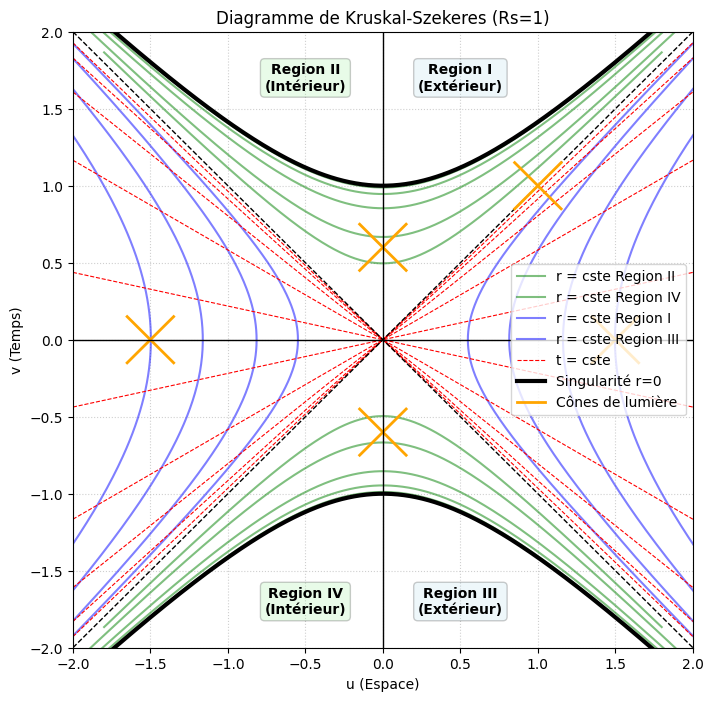

In [17]:
# Paramètres : on pose Rs = 1
def kruskal_plot():
    plt.figure(figsize=(8, 8))
    
    # Plage de valeurs pour le paramètre de tracé (rapidité)
    eta = np.linspace(-2, 2, 400)
    
    # Flags pour ajouter les labels une seule fois
    label_r_out = True
    label_r_in = True
    label_t = True
    label_cone = True
    
    # 1. Courbes à r constant (Hyperboles)
    # r > 2M (Régions I et III) : u^2 - v^2 = (r-1)e^r
    # r < 2M (Régions II et IV) : v^2 - u^2 = (1-r)e^r
    r_values = [0.2, 0.4, 0.6, 0.8, 0.9, 1.1, 1.2,1.35, 1.5, 2.0, 2.5, 3.0]
    for r in r_values:
        constant = (r - 1) * np.exp(r)
        if constant > 0: # r > Rs
            u = np.sqrt(constant) * np.cosh(eta)
            v = np.sqrt(constant) * np.sinh(eta)
            label_out = "r = cste Region I" if label_r_out else ""
            plt.plot(u, v, 'b', alpha=0.5, label=label_out)  # Région I
            label_in = "r = cste Region III" if label_r_out else ""
            plt.plot(-u, v, 'b', alpha=0.5, label=label_in) # Région III
            label_r_out = False
        else: # r < Rs
            u = np.sqrt(abs(constant)) * np.sinh(eta)
            v = np.sqrt(abs(constant)) * np.cosh(eta)
            label_ii = "r = cste Region II" if label_r_in else ""
            plt.plot(u, v, 'g', alpha=0.5, label=label_ii)  # Région II
            label_iv = "r = cste Region IV" if label_r_in else ""
            plt.plot(u, -v, 'g', alpha=0.5, label=label_iv) # Région IV
            label_r_in = False

    # 2. Courbes à t constant (Droites passant par l'origine)
    # v/u = tanh(t/2) ou u/v = tanh(t/2)
    t_values = np.linspace(-2, 2, 10)
    u_range = np.linspace(-2, 2, 100)
    for t in t_values:
        slope = np.tanh(t)
        label_t_str = "t = cste" if label_t else ""
        plt.plot(u_range, slope * u_range, 'r--', linewidth=0.8, label=label_t_str)
        label_t = False

    # 3. Singularités (r = 0) : v^2 - u^2 = 1
    u_sing = np.linspace(-2, 2, 400)
    v_sing = np.sqrt(1 + u_sing**2)
    plt.plot(u_sing, v_sing, 'k', linewidth=3, label="Singularité r=0")
    plt.plot(u_sing, -v_sing, 'k', linewidth=3)

    # 4. Horizons (r = 2M) : v = +/- u
    plt.plot([-2, 2], [-2, 2], 'k--', linewidth=1)
    plt.plot([-2, 2], [2, -2], 'k--', linewidth=1)

    # 5. Étiquettes des régions
    plt.text(0.5, 1.7, 'Region I\n(Extérieur)', fontsize=10, fontweight='bold', 
             ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2))
    plt.text(-0.5, 1.7, 'Region II\n(Intérieur)', fontsize=10, fontweight='bold',
             ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
    plt.text(0.5, -1.7, 'Region III\n(Extérieur)', fontsize=10, fontweight='bold',
             ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2))
    plt.text(-0.5, -1.7, 'Region IV\n(Intérieur)', fontsize=10, fontweight='bold',
             ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
    
    # 6. AJOUT DES CÔNES DE LUMIÈRE (du/dv = ±1)
    # On place des petits cônes à des points stratégiques
    label_cone = True
    cone_size = 0.15
    grid_points = [
        (1.5, 0),    # Région I (Extérieur)
        (-1.5, 0),   # Région III (Autre extérieur)
        (0, 0.6),    # Région II (Trou noir)
        (0, -0.6),   # Région IV (Trou blanc)
        (1.0, 1.0)   # Sur l'horizon
    ]
    
    for (u0, v0) in grid_points:
        # Droites v = u + c et v = -u + c
        label_cone_str = "Cônes de lumière" if label_cone else ""
        plt.plot([u0-cone_size, u0+cone_size], [v0-cone_size, v0+cone_size], 'orange', lw=2, label=label_cone_str)
        plt.plot([u0-cone_size, u0+cone_size], [v0+cone_size, v0-cone_size], 'orange', lw=2)
        label_cone = False
        

    # Cosmétique
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.xlabel('u (Espace)')
    plt.ylabel('v (Temps)')
    plt.title('Diagramme de Kruskal-Szekeres (Rs=1)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc = 'right')
    plt.show()

kruskal_plot()


Les géodésiques sont simplement des cônes de lumière à 45°, comme dans l'espace de Minkowski (on a construit la métrique telle quelle).



Une fois tous ces systèmes de coordonnées définis, étudions et comparons les trajectoires de notre surface en chute libre avec quelques cônes de lumière :

C:\Users\padou\AppData\Local\Temp\ipykernel_8792\3776216645.py:19: RuntimeWarning: divide by zero encountered in log
  t = t0 + (r0 - r) / c - r_s/c*np.log(np.abs((r-r_s)/(r0-r_s)))


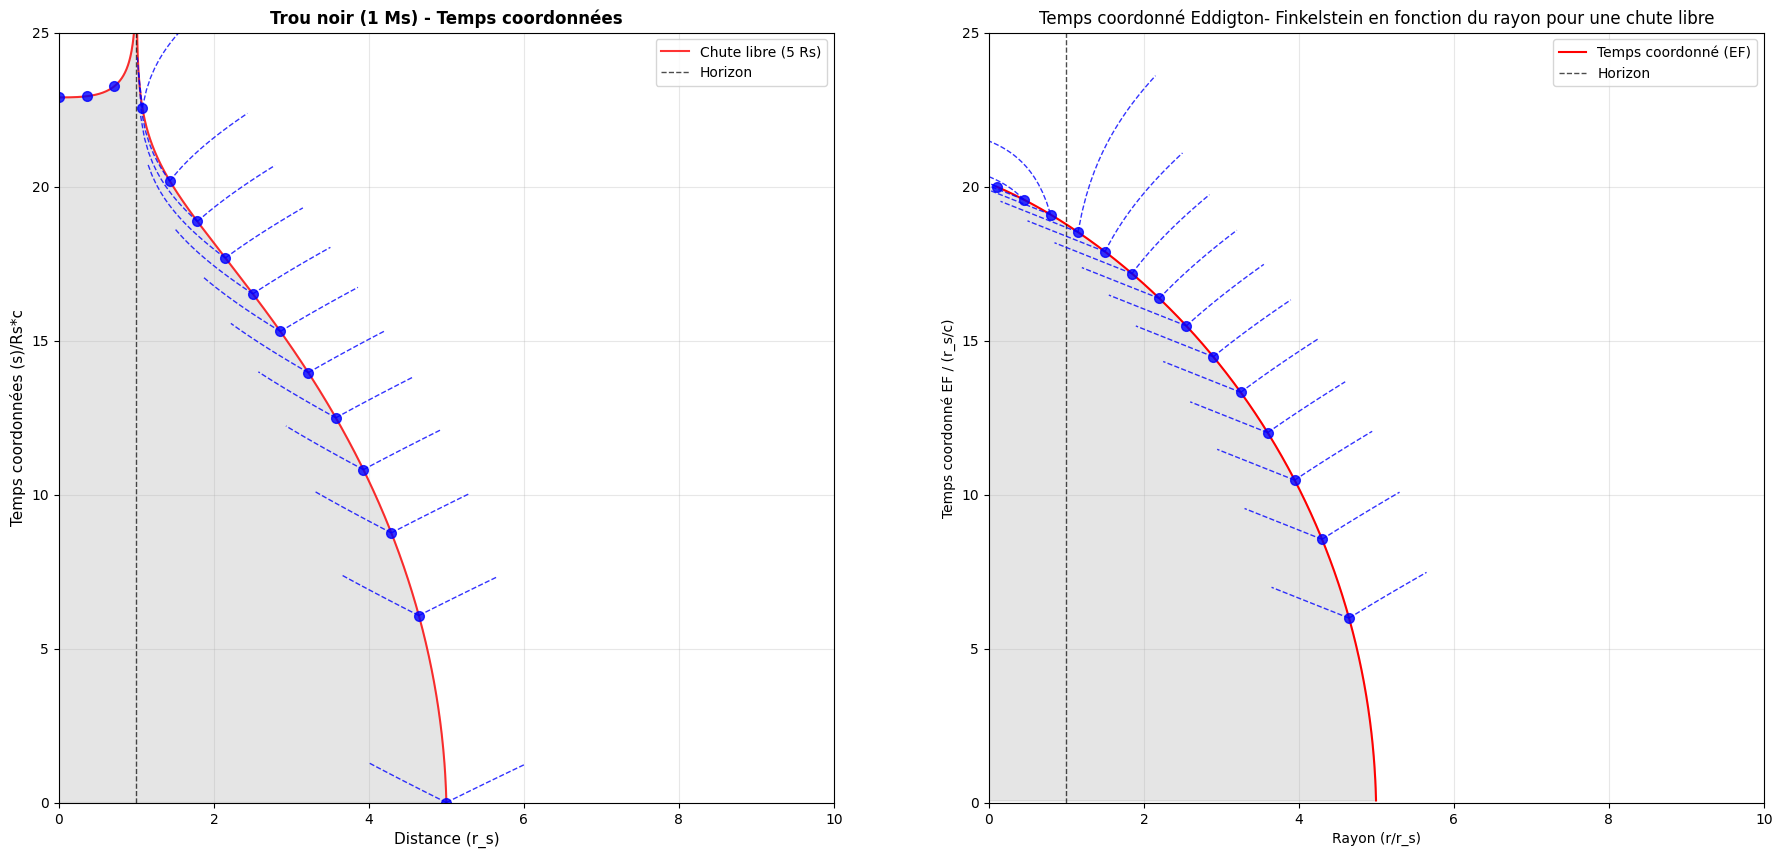

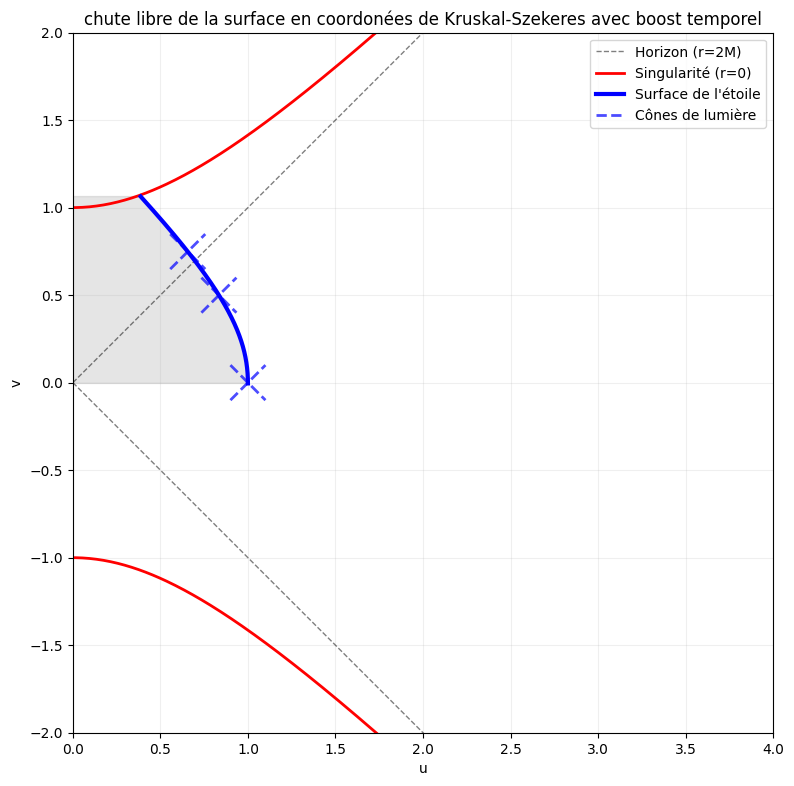

In [18]:
fig, axes = plt.subplots(1,2,figsize=(22, 10))

ax = axes[0]
M_bh = M_sun
r_s = schwarzschild_radius(M_bh)
r_bh = np.linspace(5*r_s, r_s*0.001, 1000)  # Decroissant de 5*r_s a r_s
tau_bh = ff_cordinate_time(5*r_s, r_bh, M_bh)
ax.plot(r_bh/r_s, tau_bh/r_s*c, 'r-',alpha=0.8, linewidth=1.5, label='Chute libre (5 Rs)')
ax.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Horizon')
ax.set_xlabel('Distance (r_s)', fontsize=11)
ax.set_ylabel('Temps coordonnées (s)/Rs*c', fontsize=11)
ax.set_title('Trou noir (1 Ms) - Temps coordonnées', fontweight='bold')
ax.grid(True, alpha=0.3)

# Limites des axes: x de 0 à 25, y de 0 à 25
ax.set_xlim(0, 10)
ax.set_ylim(0, 25)

# Points régulièrement espacés SUR LA COURBE ROUGE
indices = np.linspace(0, len(r_bh)-1, 15, dtype=int)
for i in indices:
    ax.plot(r_bh[i]/r_s, tau_bh[i]/r_s*c, 'bo', markersize=7, alpha=0.8)
    if r_bh[i] > r_s:
        r_out = np.linspace(r_bh[i], r_bh[i]+r_s, 20)
        t_out = schwarzchild_geo_p(tau_bh[i], r_bh[i], r_out, M_bh)
        ax.plot(r_out/r_s, t_out/r_s*c, 'b--', linewidth=1, alpha=0.8)
        r_in = np.linspace(r_bh[i], r_bh[i]-r_s, 20)
        r_in = np.clip(r_in, r_s, None)  # Enlever les valeurs < r_s
        t_in = schwarzchild_geo_m(tau_bh[i], r_bh[i], r_in, M_bh)
        ax.plot(r_in/r_s, t_in/r_s*c, 'b--', linewidth=1, alpha=0.8)
    
ax.fill_betweenx(tau_bh/r_s*c, -5, r_bh/r_s, color='gray', alpha=0.2) # Zone intérieure
ax.legend()

ax2 = axes[1]
def ff_EF_time(r0, r, M):
    """
    Calcul du temps coordonné par intégration numérique.
    r décroît de r0 vers 0, donc on separe entre les deux régions:
- r > r_s : descente vers le trou noir
- r < r_s : chute libre à l'intérieur du trou noir
    dt/dr = sqrt(1-r_s/r0) / (1-r_s/r) * (-1/(c*sqrt(r_s/r - r_s/r0)))
    """
    r_s = schwarzschild_radius(M)
    r = np.asarray(r)
    dt_dr = np.zeros_like(r, dtype=float)
    
    # Masques pour les deux régions
    mask_out = r > r_s  # Région r > r_s (reachable)
    mask_in = r < r_s   # Région r < r_s (intérieur)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # Région extérieure
        if np.any(mask_out):
            dt_dr[mask_out] = np.sqrt(1 - r_s/r0) / (1 - r_s/r[mask_out]) * (-1) / (c * np.sqrt(r_s/r[mask_out] - r_s/r0)) + 1/c * 1/(r[mask_out]/r_s - 1)
        
        # Région intérieure
        if np.any(mask_in):
            dt_dr[mask_in] = np.sqrt(1 - r_s/r0) / (1 - r_s/r[mask_in]) * (-1) / (c * np.sqrt(r_s/r[mask_in] - r_s/r0)) + 1/c * 1/(r[mask_in]/r_s - 1)
            #dt_dr[mask_in] = np.clip(dt_dr[mask_in], -2, None)  # Clip à -2 pour régulariser à r_s
    
    dr = np.gradient(r)
    t_coord = np.cumsum((dt_dr * dr))
    t_coord += 20*r_s/c  # Normaliser pour que t=0 à r=r0
    return t_coord


M =  M_sun  # Masse du trou noir en kg
r_s = schwarzschild_radius(M)
r0 = 5 * r_s  # Rayon initial de chute libre

r = np.linspace(0.1 * schwarzschild_radius(M), 5 * schwarzschild_radius(M), 1000)  # Rayon de chute libre
t_coord = ff_EF_time(r0, r, M)
ax2.plot(r/r_s, t_coord/r_s*c, label='Temps coordonné (EF)',color = 'red')
ax2.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Horizon')

ax2.set_xlabel('Rayon (r/r_s)')
ax2.set_ylabel('Temps coordonné EF / (r_s/c)')
ax2.set_title('Temps coordonné Eddigton- Finkelstein en fonction du rayon pour une chute libre')
ax2.legend()
ax2.fill_betweenx(t_coord/r_s*c, -5, r/r_s, color='gray', alpha=0.2) # Zone intérieure

ax2.grid(alpha=0.3)
indices = np.linspace(0, len(r)-1, 15, dtype=int)
for i in indices:
    ax2.plot(r[i]/r_s, t_coord[i]/r_s*c, 'bo', markersize=7, alpha=0.8)
    if r[i] > r_s:
        r_out = np.linspace(r[i], r[i]+r_s, 20)
        t_out = ef_geo_p(t_coord[i], r[i], r_out, M)
        ax2.plot(r_out/r_s, t_out/r_s*c, 'b--', linewidth=1, alpha=0.8)
        r_in = np.linspace(r[i], r[i]-r_s, 20)
        t_in = ef_geo_m(t_coord[i], r[i], r_in, M)
        ax2.plot(r_in/r_s, t_in/r_s*c, 'b--', linewidth=1, alpha=0.8)
    else:
        r_out = np.linspace(r[i]-r_s, r[i], 20) #ici on prend en compte le fait que les geodesiques ne peuvent pas aller au dela de r_s et decroissent vers 0
        t_out = ef_geo_p(t_coord[i], r[i], r_out, M)
        ax2.plot(r_out/r_s, t_out/r_s*c, 'b--', linewidth=1, alpha=0.8)
        r_in = np.linspace(r[i], r[i]-r_s, 20)
        r_in = np.clip(r_in, 0, None)  # Éviter les valeurs trop proches de zéro
        t_in = ef_geo_m(t_coord[i], r[i], r_in, M)
        ax2.plot(r_in/r_s, t_in/r_s*c, 'b--', linewidth=1, alpha=0.8)

# Limites des axes: x de 0 à 25, y de 0 à 25
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 25)



M = 0.5
rs = 1.0  # Rayon de Schwarzschild
Ri = 10.0 * M  # Rayon initial (5.0 dans ces unités)
dt_shift = 44 * M  # Décalage temporel spécifié dans le document

def generate_kruskal_path():
    # 1. Paramétrage cycloïdal (eta de 0 à pi)
    eta = np.linspace(0, np.pi - 0.001, 2000)
    r = (Ri / 2) * (1 + np.cos(eta))
    
    # 2. Calcul des termes de temps (MTW 31.10)
    k = np.sqrt(Ri/rs - 1)
    # Partie régulière de t/rs
    t_reg = k * (eta + (Ri/(2*rs)) * (eta + np.sin(eta)))
    
    # 3. Calcul de V+U et V-U pour éviter la divergence
    # V+U = exp((t + r*)/2rs)
    # V-U = +/- exp(-(t - r*)/2rs)
    # On gère analytiquement le produit exp(log|r-rs|) * sqrt|r-rs|
    
    # Terme de l'horizon : tan(eta/2) vaut k quand r = rs
    # On utilise la simplification : sqrt(r/rs - 1) * exp(t/2rs)
    # qui reste finie à l'horizon.
    
    # t_log = rs * ln |(k + tan)/(k - tan)|
    # r_star_log = rs * ln |r/rs - 1|
    
    # Le terme combiné (t + r*)/(2rs) sans les logs divergents :
    # On calcule l'argument de l'exponentielle de manière stable
    exp_arg_plus = (t_reg + r/rs) / 2.0
    
    # Facteur correcteur pour les logs :
    # sqrt|r/rs-1| * exp(0.5 * ln|(k+tan)/(k-tan)|)
    with np.errstate(divide='ignore', invalid='ignore'):
        term_corr = np.sqrt(np.abs(r/rs - 1)) * np.sqrt(np.abs((k + np.tan(eta/2)) / (k - np.tan(eta/2))))
    
    # Coordonnées de Kruskal de base (non boostées)
    # On multiplie par exp(r/2rs) qui vient de r*
    A = np.exp(exp_arg_plus) * term_corr * np.exp(r/(2*rs)) # C'est V+U
    B = (r/rs - 1) * np.exp(r/rs) / A # C'est V-U via la relation métrique
    
    U_base = (A - B) / 2
    V_base = (A + B) / 2
    
    # 4. Application de la translation temporelle (t -> t + 42.8M)
    # Cela correspond à une transformation de Lorentz (boost) dans le plan (U, V)
    alpha = dt_shift / (2 * rs)
    U = U_base * np.cosh(alpha) - V_base * np.sinh(alpha)
    V = V_base * np.cosh(alpha) - U_base * np.sinh(alpha)
    
    return U, V

# --- Tracé du graphique ---
U, V = generate_kruskal_path()

# Clipping de la trajectoire pour ne pas dépasser la singularité (v² - u² = 1)
singularity_distance = V**2 - U**2  # Distance à la singularité
clip_mask = singularity_distance <0.99  # Garder seulement les points avant la singularité (avec marge)
U_clipped = U[clip_mask]
V_clipped = V[clip_mask]

fig, ax = plt.subplots(figsize=(8, 8))

# Horizon (r=2M)
ax.plot([0, 5], [0, 5], 'k--', lw=1, alpha=0.5, label="Horizon (r=2M)")
ax.plot([0, 5], [0, -5], 'k--', lw=1, alpha=0.5)

# Singularité (r=0) -> V^2 - U^2 = 1
u_s = np.linspace(-5, 5, 1000)
v_s = np.sqrt(1 + u_s**2)
ax.plot(u_s, v_s, 'r', lw=2, label="Singularité (r=0)")

u_s2 = np.linspace(-5, 5, 1000)
v_s2 = -np.sqrt(1 + u_s2**2)
ax.plot(u_s2, v_s2, 'r', lw=2)


# Surface de l'étoile (courbe clippée)
ax.plot(U_clipped, V_clipped, 'b', lw=3, label="Surface de l'étoile")
ax.fill_betweenx(V_clipped, -5, U_clipped, color='gray', alpha=0.2) # Zone intérieure

# Cônes de lumière à des valeurs spécifiques de v (1.0, 0.75, 0.5)
v_targets = [ 0.75, 0.5]
cone_points = [(1, 0, 0)]  # Ajouter le point d'origine pour les cônes à l'horizon

for v_target in v_targets:
    # Trouver l'indice le plus proche de v_target
    idx = np.argmin(np.abs(V - v_target))
    if idx < len(U):
        cone_points.append((U[idx], V[idx], v_target))

# Tracer les cônes
for cone_idx, (u0, v0, v_label) in enumerate(cone_points):
    # Cône sortant (pente +1 : v = u + cste)
    u_cone_out = np.linspace(u0 - 0.1, u0 + 0.10, 100)
    v_cone_out = u_cone_out + (v0 - u0)
    
    # Cône entrant (pente -1 : v = -u + cste)
    u_cone_in = np.linspace(u0 - 0.1, u0 + 0.10, 100)
    v_cone_in = -u_cone_in + (v0 + u0)
    
    # Ajouter le label uniquement sur le premier cône
    label_str = "Cônes de lumière" if cone_idx == 0 else ""
    ax.plot(u_cone_out, v_cone_out, 'b--', lw=2, alpha=0.7, label=label_str)
    ax.plot(u_cone_in, v_cone_in, 'b--', lw=2, alpha=0.7)
    
    # Marquer le point sur la trajectoire
    ax.plot(u0, v0, color='orange', markersize=6)

# Échelles identiques à l'image (b)
ax.set_xlim(0, 4)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_title('chute libre de la surface en coordonées de Kruskal-Szekeres avec boost temporel')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()


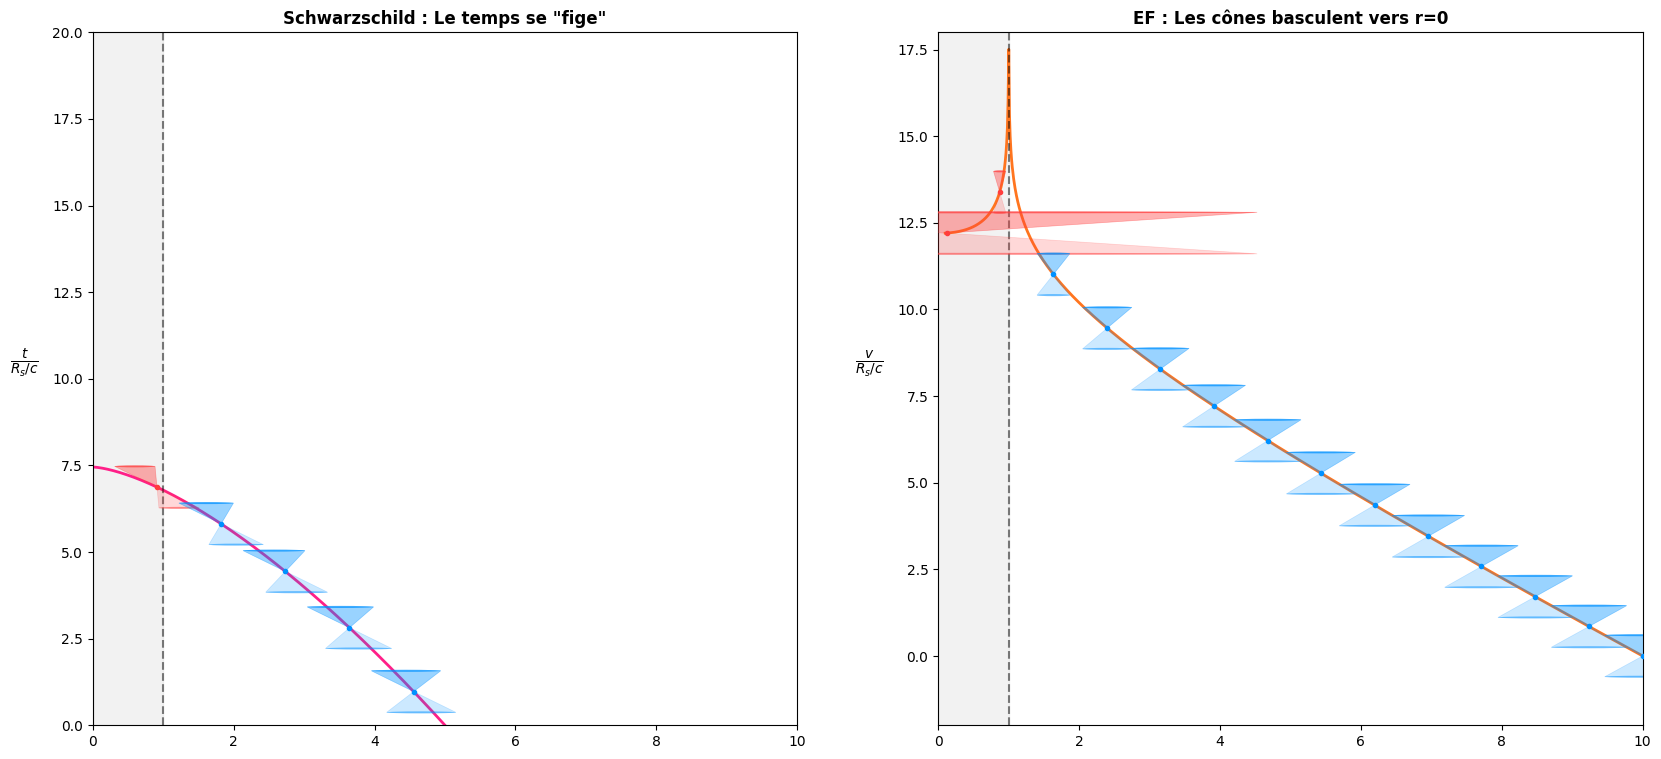

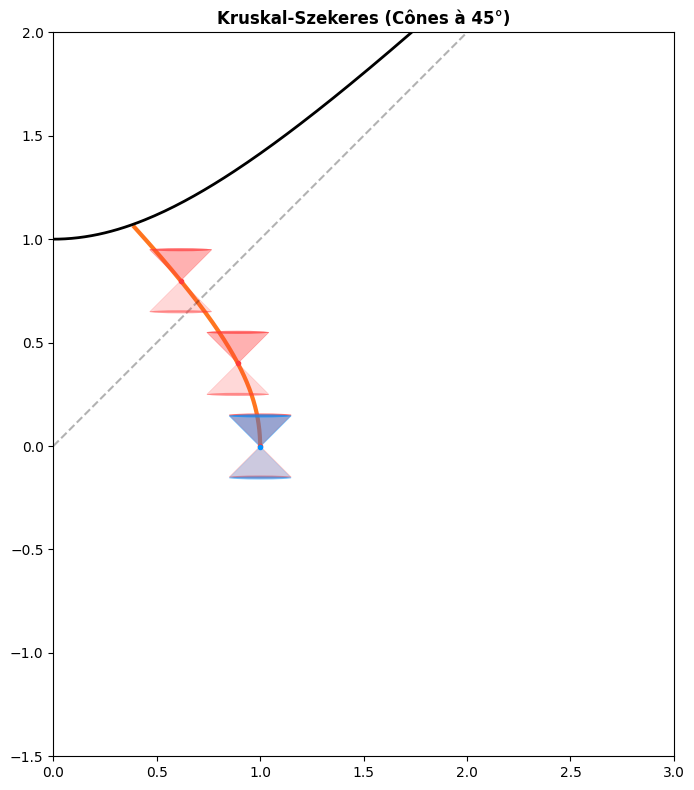

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- Configuration et Constantes ---
M_sun = 1.0  # Masse solaire normalisée
c = 1.0
def schwarzschild_radius(M): return 1.0  # Rs = 1 pour la clarté des graphiques

# Fonctions de géodésiques pour EF (utilisées dans les boucles)
def ef_geo_p(t0, r0, r, M): return t0 + (r - r0) + 2*np.log(np.abs((r-1)/(r0-1)) + 1e-5)
def ef_geo_m(t0, r0, r, M): return t0 - (r - r0)

# --- FONCTION DE DESSIN DES CÔNES AFFINÉE ---
def draw_causal_cone(ax, r0, t0, rs, coord_type, size=0.4):
    """
    Dessine un cône causal stylisé. 
    'size' contrôle la hauteur visuelle.
    """
    if r0 <= 0.05: return
    
    # Calcul des pentes locales dt/dr
    if coord_type == 'schwarzschild':
        factor = np.abs(1 - rs/r0)
        if factor < 0.001: factor = 0.001
        slope_p, slope_m = 1.0/factor, -1.0/factor
    elif coord_type == 'kruskal':
        slope_p, slope_m = 1.0, -1.0
    else: # Eddington-Finkelstein
        slope_m = -1.0
        denom = (1 - rs/r0)
        if np.abs(denom) < 0.02: denom = 0.02 * np.sign(denom)
        slope_p = (1 + rs/r0) / denom

    # Ajustement pour l'aspect ratio (Y est plus grand que X)
    # On réduit la largeur radiale pour que les cônes ne soient pas trop "gras"
    h = size 
    dr_p = h / slope_p
    dr_m = h / slope_m
    
    # Couleur selon la région
    color = "#0091ff" if r0 > rs else "#ff3d3d" # Bleu extérieur, Rouge intérieur
    
    # --- CÔNE FUTUR ---
    pts_f = np.array([[r0, t0], [r0 + dr_p, t0 + h], [r0 + dr_m, t0 + h]])
    ax.fill(pts_f[:,0], pts_f[:,1], color=color, alpha=0.4, edgecolor=color, lw=0.5, zorder=10)
    
    # Base (Perspective)
    width = np.abs(dr_p - dr_m)
    ax.add_patch(Ellipse((r0 + (dr_p + dr_m)/2, t0 + h), width, h*0.1, 
                         facecolor=color, alpha=0.7, zorder=11))
    
    # Sommet
    ax.plot(r0, t0, 'o', color=color, markersize=3, zorder=12)

    # --- CÔNE PASSÉ  ---
    pts_p = np.array([[r0, t0], [r0 - dr_p, t0 - h], [r0 - dr_m, t0 - h]])
    ax.fill(pts_p[:,0], pts_p[:,1], color=color, alpha=0.2, edgecolor=color, lw=0.5, zorder=9)
    ax.add_patch(Ellipse((r0 - (dr_p + dr_m)/2, t0 - h), width, h*0.1, 
                         facecolor=color, alpha=0.5, zorder=8)) 

# --- 1. SCHWARZSCHILD & EDDINGTON-FINKELSTEIN ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# GAUCHE : SCHWARZSCHILD
ax = axes[0]
r_s = 1.0
r_bh = np.linspace(10, 0.001, 1000)
tau_bh = (2/3) * (5**1.5 - r_bh**1.5) # Approximation chute libre

ax.plot(r_bh/r_s, tau_bh*c, "#ff1f88", lw=2, label='Chute libre')
ax.axvline(1, color='black', ls='--', alpha=0.5)
ax.fill_betweenx([-2, 30], 0, 1, color='gray', alpha=0.1)

indices = np.linspace(0, len(r_bh)-1, 12, dtype=int)
for i in indices:
    draw_causal_cone(ax, r_bh[i]/r_s, tau_bh[i], r_s, 'ef', size=0.6)

ax.set_xlim(0, 10); ax.set_ylim(0, 20)
ax.set_title('Schwarzschild : Le temps se "fige"', fontweight='bold')
ax.set_ylabel(r'$\frac{t}{R_s/c}$', rotation=0, labelpad=20, fontsize=14)

# DROITE : EDDINGTON-FINKELSTEIN
ax2 = axes[1]
# Re-calcul du temps EF pour plus de précision
r_vals = np.linspace(0.1, 10, 1000)
t_ef = r_vals + np.log(np.abs(r_vals-1) + 1e-5) # t_coord simplifié pour démo
t_ef = np.max(t_ef) - t_ef # Inversion pour chute

ax2.plot(r_vals/r_s, t_ef, '#ff751f', lw=2)
ax2.axvline(1, color='black', ls='--', alpha=0.5)
ax2.fill_betweenx([-5, 30], 0, 1, color='gray', alpha=0.1)

for i in np.linspace(2, len(r_vals)-1, 14, dtype=int):
    draw_causal_cone(ax2, r_vals[i]/r_s, t_ef[i], r_s, 'schwarzschild', size=0.6)

ax2.set_xlim(0, 10); ax2.set_ylim(-2, 18)
ax2.set_title('EF : Les cônes basculent vers r=0', fontweight='bold')
ax2.set_ylabel(r'$\frac{v}{R_s/c}$', rotation=0, labelpad=20, fontsize=14)

# --- 2. KRUSKAL-SZEKERES ---
U, V = generate_kruskal_path() # Utilise ta fonction existante
U_clipped = U[V**2 - U**2 < 0.98]
V_clipped = V[V**2 - U**2 < 0.98]

fig2, ax3 = plt.subplots(figsize=(8, 8))
ax3.plot(U_clipped, V_clipped, '#ff751f', lw=3, label="Surface de l'étoile")

# Singularité et Horizon
u_s = np.linspace(-4, 4, 500)
ax3.plot(u_s, np.sqrt(1 + u_s**2), 'black', lw=2)
ax3.plot([0, 5], [0, 5], 'k--', alpha=0.3)

# Cônes Kruskal (toujours à 45°)
for v_t in [0.8, 0.4, 0.0, -0.5]:
    idx = np.argmin(np.abs(V - v_t))
    draw_causal_cone(ax3, U[idx], V[idx], 1.0, 'kruskal', size=0.15)

ax3.set_xlim(0, 3); ax3.set_ylim(-1.5, 2)
ax3.set_aspect('equal')
ax3.set_title('Kruskal-Szekeres (Cônes à 45°)', fontweight='bold')

plt.tight_layout()
plt.show()

On aperçoit que dans les deux premiers systèmes de coordonnées, le comportement de la lumière change en $r=R_S$. Cependant, l'interprétation classique des trous noirs est mieux retranscrite dans les coordonnées d'Eddington-Finkelstein. Les cônes de lumière se resserrent et se ferment progressivement. L'”horizon" pour la surface correspond alors au moment où la géodésique sortante est verticale. Tandis qu'en coordonnées de Kruskal-Szekeres une grande partie du sens physique classique est plus difficilement visible.


### luminositée

Intéressons-nous alors à ce que perçoit réellement l'observateur. On l'a déjà vu, pour lui la surface semble se figer en $r=R_S$ *a priori*. Cependant, d'autres phénomènes bien plus compliqués sont à l'œuvre et ce que l'on observe réellement est un agrégat d'effet d'optique, de redshifts et de trajectoires de photons toutes plus originales les unes que les autres dues à la courbure extrême de l'espace-temps aux alentours de $R_S$. Si le rendu optique de tels effets est trop ambitieux pour ce projet, il est possible car entièrement déterministe (*cf.* [exemple de rendu simulé numériquement](https://www.youtube.com/watch?v=Ob4BE3m9vqU)). Nous pouvons malgré tout étudier en termes d'intensité lumineuse et de redshift ce qu'il se passe. Considérons une antenne émettrice de photons qui suit la surface ainsi qu'un observateur immobile à une distance R grande.



Étudions tout d'abord le redshift lorsque la surface se rapproche de $R_S$ : 

Par définition, on a, en notant $\nu_e$ et $\nu_r$ les fréquences à l'émission et à la réception :

 $$ 1+z= \frac{\nu_e}{\nu_r} = \frac{E_e}{E_r} = \frac{p_{\mu}^{\text{em}} u^{\mu}_{\text{em}}}{p_{\mu}^{\text{obs}} u^{\mu}_{\text{obs}}}

 $$



où $p$ est la quantité de mouvement du photon respectivement au départ et à l'arrivée. La quadrivitesse $u$ est celle respectivement de l'émetteur et de l'observateur.



 Pour l'observateur à R, on a naturellement $u^i = 0$ ce qui donne en paramétrant avec $\tau$ tel que $u^2 = -1$ en unités normales : 

$$ u^{\mu}_{\text{obs}} = \left\{ \frac{1}{\sqrt{1-\frac{R_s}{R}}}, 0, 0, 0 \right\} $$



Pour l'émetteur à l'altitude r, on a toujours, en paramétrant avec $\tau$ $u^{\mu}_{\text{em}} = \frac{dx_{\text{em}^{\mu}}}{d\tau}=\gamma \frac{dx_{\text{em}^{\mu}}}{dt} $. Ainsi :

$$ u^{\mu}_{\text{em}} = \gamma \left\{ \frac{1}{\sqrt{1-\frac{R_s}{r}}}, \sqrt{1-\frac{R_S}{r}} v, 0, 0 \right\} $$



Étudions la quadriquantité de mouvement du photon à l'émission et à la reception :



On commence par noter que, la métrique étant indépendante du temps  $ \xi_{\mu}= \partial_t$ est un Killing. Ainsi, $\xi_{\mu}p^{\mu} = cste = p^0$ eszt conservé. De plus, on a $\underline{P}^2 = 0  = -\frac{p_0^2}{1-\frac{R_S}{r}} + \left(1-\frac{R_S}{r}\right)p_r^2$ pour des photons radiaux (on a inversé la métrique)( (on prend la solution positive car on s'intéresse aux photons sortants). D'où :



$$p_{\mu} = \left\{ p_0, \frac{p_0}{1-\frac{R_S}{r}}, 0, 0 \right\}$$



On combine les produits scalaires  : 



$$E_e =  -p_{\mu}^{\text{em}} u^{\mu}_{\text{em}} = \gamma (1-v) \frac{p_0}{\sqrt{1-\frac{R_s}{r}}} \quad ; \quad E_r = -p_{\mu}^{\text{obs}} u^{\mu}_{\text{obs}} = \frac{p_0}{\sqrt{1-\frac{R_s}{R}}} $$



Finalement, on a  : 



$$1+z = \gamma (1-v) \sqrt{\frac{1-\frac{R_s}{R}}{1-\frac{R_s}{r}}}$$



Calculons alors $v$ et $\gamma$. Comme précisé auparavant, on a $$\frac{dr}{dt} = -\left(1-\frac{R_S}{r}\right)\sqrt{1-\frac{1-\frac{R_S}{r}}{1-\frac{R_S}{r_0}}}$$ pour la surface en chute libre. D'où $$v = \sqrt{g_{ij}u^iu^j} = -\sqrt{1-\frac{1-\frac{R_S}{r}}{1-\frac{R_S}{r_0}}} $$



On utilise alors l'information $r\sim R_S$ : 



À l'ordre dominant : 

$$\begin{cases} 



v \sim -1 \\ 



\gamma \propto \frac{1}{\sqrt{1-\frac{R_s}{r}}} 



\end{cases}$$



Ainsi :



$$1+z \propto \frac{1}{1-\frac{R_S}{r}}$$



Relions cette expression à t. On note t le temps en coordonnée où l'observateur reçoit le signal. Ce signal a été émis à un temps $t'$ $\Delta t$ avant $t$, ou $\Delta t$ correspond au temps de trajet du photon. On a donc $t=t'+\Delta t$. Ainsi, il s'agit d'exprimer ces différents temps :



Les photons sont emis de maniere radiale d'où : 

$$\frac{dr}{dt} = 1-\frac{R_S}{r}$$

Apres integration :

$$\Delta t =R_S \ln \left( \frac{R-R_S}{r-R_S}\right) +R-r$$



Pour le temps $t'$ de l'émetteur en $r\sim R_S$: 



$$\frac{dr}{dt} = -\left(1-\frac{R_S}{r}\right)\sqrt{1-\frac{1-\frac{R_S}{r}}{1-\frac{R_S}{r_0}}} \sim -\left(1-\frac{R_S}{r}\right)$$



Alors en intégrant similairement et en sommant on a :



$$t\sim 2R_S\ln \left( \frac{R-R_S}{r-R_S}\right) +2R-2r $$

Comme on a supposé R grand, $R-r\sim R$ , ainsi à un facteur de proportionnalité près :

$$r-R_S \propto e^{-\frac{t}{2R_S}}$$



On a donc finalement : 

$$1+z \propto e^{\frac{t}{2R_S}}$$



L'étoile devient alors infiniment redshiftée lorsque r tend vers $R_S$ dans ce modèle.













## III. Dynamique d'effondrement d'une étoile

Le théorème de **Birkhoff** précise que la métrique en dehors de l'étoile en effondrement est la **métrique de Schwarzschild**, due à la symétrie du système et à la statique de la géométrie extérieure.


### A) Solution extérieure

**Métrique de Schwarzschild :**
$$ds^2 = -\left(1 - \frac{R_g}{R}\right) c^2 dt^2 + \left(1 - \frac{R_g}{R}\right)^{-1} dR^2 + R^2 d\Omega^2$$

On note $\lambda$ le paramètre affine et $R_g = \frac{2MG}{c^2}$.

$\mathcal{L} = \frac{1}{2} g_{\mu\nu} \dot{x}^\mu \dot{x}^\nu$ avec $g_{\mu\nu} = \begin{pmatrix} 1-\frac{R_g}{R} & 0 & 0 & 0 \\ 0 & \frac{1}{1-\frac{R_g}{R}} & 0 & 0 \\ 0 & 0 & R^2 & 0 \\ 0 & 0 & 0 & R^2 \sin^2 \theta \end{pmatrix}$

$$\mathcal{L} = \frac{1}{2} \left[ \left(1 - \frac{R_g}{R}\right) \left(\frac{dT}{d\lambda}\right)^2 + \frac{1}{1 - \frac{R_g}{R}} \left(\frac{dR}{d\lambda}\right)^2 + R^2 \left(\frac{d\theta}{d\lambda}\right)^2 + R^2 \sin^2 \theta \left(\frac{d\varphi}{d\lambda}\right)^2 \right]$$

**Équations d'Euler-Lagrange :** $\frac{d}{d\lambda} \left( \frac{\partial \mathcal{L}}{\partial \dot{x}^\mu} \right) = \frac{\partial \mathcal{L}}{\partial x^\mu}$

$$
\begin{cases} 
\frac{d}{d\lambda} \left[ (1 - \frac{R_g}{R}) \frac{dT}{d\lambda} \right] = 0 \\
\frac{d}{d\lambda} \left( R^2 \sin^2 \theta \frac{d\varphi}{d\lambda} \right) = 0 \\
\frac{d}{d\lambda} \left( R^2 \frac{d\theta}{d\lambda} \right) = R^2 \sin(2\theta) \left( \frac{d\varphi}{d\lambda} \right)^2 \\
\frac{d}{d\lambda} \left( \frac{1}{1 - \frac{R_g}{R}} \frac{dR}{d\lambda} \right) = -\frac{R_g}{2R^2} \left[ \left(\frac{dT}{d\lambda}\right)^2 + \frac{1}{(1 - \frac{R_g}{R})^2} \left(\frac{dR}{d\lambda}\right)^2 \right] + 2R \left[ \left(\frac{d\theta}{d\lambda}\right)^2 + \sin^2 \theta \left(\frac{d\varphi}{d\lambda}\right)^2 \right]
\end{cases}
$$

On se place dans le plan équatorial : $\theta = \frac{\pi}{2}$, $\dot{\theta} = 0$. D'où :

$$
\begin{cases} 
(1 - \frac{R_g}{R}) \dot{T} = \frac{\mathcal{E}}{c^2} \\
R^2 \dot{\varphi} = \mathcal{L} \\
\frac{d}{d\lambda} (R^2 \dot{\theta}) = 0
\end{cases}
$$

D'où en utilisant la norme du quadrivecteur vitesse : 

$$-Kc^2 = g_{\mu\nu} u^\mu u^\nu = -\left(1 - \frac{R_g}{R}\right) (c\dot{T})^2 + \frac{\dot{R}^2}{1 - \frac{R_g}{R}} + R^2 \dot{\theta}^2 + R^2 \dot{\varphi}^2$$

$$\Leftrightarrow -Kc^2 = -\left(1 - \frac{R_g}{R}\right)^{-1} \frac{\mathcal{E}^2}{c^2} + \left(1 - \frac{R_g}{R}\right)^{-1} \dot{R}^2 + \frac{\mathcal{L}^2}{R^2}$$

$$\Leftrightarrow \dot{R}^2 = \frac{\mathcal{E}^2}{c^2} - Kc^2 + Kc^2 \frac{R_g}{R} - \frac{\mathcal{L}^2}{R^2} + \frac{\mathcal{L}^2 R_g}{R^3}$$


Pour un observateur doté d'un mouvement radial : $\mathcal{L} = 0$, $K = 1$.

$$\Rightarrow \dot{R}^2 = \frac{\mathcal{E}^2}{c^2} - c^2 \left(1 - \frac{R_g}{R}\right)$$

Condition initiale : $\dot{R}(0) = 0$ en $R_0$, soit $\frac{\mathcal{E}^2}{c^2} = c^2 \left(1 - \frac{R_g}{R_0}\right)$.

L'équation des géodésiques radiales est :
> **$$R \dot{R}^2 + c^2 \frac{R_g}{R_0} R = c^2 R_g$$**


### B) Solution intérieure

**Métrique de Friedmann-Lemaître-Robertson-Walker (FLRW) :**
$$ds^2 = -c^2 dt^2 + a^2(t) \left[ \frac{dr^2}{1 - kr^2} + r^2 d\Omega^2 \right] \quad \text{avec } k \in \{0, -1, +1\}$$

Elle représente un espace-temps homogène et isotrope en contraction.

* **Fluide comobile :** Le fluide est au repos par rapport à la géométrie, soit $\vec{u} = u^0 \vec{e}_0$.
    $(u^0)^2 g_{00} = -c^2 \implies u^0 = \frac{c}{\sqrt{-g_{00}}} = c$.
    Par conséquent, le temps propre et le temps de FLRW sont identiques.

* **Fluide parfait :** $T_{\mu\nu} = \rho u_\mu u_\nu$ avec pression $p=0$.
    Conservation de l'énergie : $\nabla_\mu T^\mu{}_\nu = 0 \Leftrightarrow \nabla_\mu (g^{\mu\sigma} T_{\sigma\nu}) = 0$.

    **Équation de Friedmann (conservation) :** $\dot{\rho} + 3 \frac{\dot{a}}{a} \rho = 0$.
    Ce qui donne : $\rho(t) = \rho_0 \left( \frac{a_0}{a(t)} \right)^3$.

* **Équation d'Einstein :** $G_{\mu\nu} = \frac{8\pi G}{c^4} T_{\mu\nu}$.
    La composante $G_{00} = \frac{8\pi G}{c^4} T_{00}$ donne :
    $$\left(\frac{\dot{a}}{a}\right)^2 + \frac{kc^2}{a^2} = \frac{8\pi G}{3} \rho$$

    $$\Rightarrow \boxed{a \dot{a}^2 + kc^2 a = \frac{8\pi G}{3} \rho_0 a_0^3}$$
    Note : $k=1$ dans un tel espace-temps (effondrement d'une sphère de courbure intrinsèque positive).

**C) Surface limitrophe**

En $r = r_s$, surface amovible pour la solution intérieur au repos.

On veut une continuité parfaite entre les deux solutions :
* **Intérieur** à $r = r_s$ : $ds^2 = -c^2 d\tau^2 + a(t)^2 x_s^2 d\Omega^2$
* **Extérieur** : $ds^2 = -c^2 \left( 1 - \frac{R_g}{R} \right) dT^2 + \frac{dR^2}{1 - \frac{R_g}{R}} + R^2 d\Omega^2$

D'où, par identification :
$$R(t) = a(t) x_s$$
$$d\tau^2 = \left( 1 - \frac{R_g}{R} \right) dT^2 - \frac{dR^2}{c^2 \left( 1 - \frac{R_g}{R} \right)}$$

$$\frac{dR}{dt} = \dot{a} r_s$$

Donc, $$\left( \frac{dT}{d\tau} \right)^2 = \frac{1}{1 - \frac{R_g}{R(t)}} \left( 1 + \frac{(\frac{dR}{d\tau})^2}{c^2 (1 - \frac{R_g}{R(t)})} \right)$$
$$\Leftrightarrow c dT = \frac{d\tau}{\sqrt{1 - \frac{R_g}{R}}} \sqrt{ 1 + \frac{(\dot{R}/c)^2}{(1 - R_g/R)} }$$
$$\Rightarrow dT = d\tau \sqrt{ \frac{ 1 + \frac{\dot{a}^2 r_s^2}{c^2 (1 - R_g / (a(t) r_s))} }{ 1 - \frac{R_g}{a(t) r_s} } }$$

On rappelle $\dot{a}^2 + k c^2 a = \frac{8 \pi G}{3} \rho_0 a^3$

Donc, $$\frac{R}{r_s} \frac{\dot{R}^2}{r_s^2} + k c^2 \frac{R}{r_s} = \frac{8 \pi G}{3} \rho_0 \frac{R^3}{r_s^3}$$
$$ie \quad R \dot{R}^2 + k c^2 R r_s^2 = \frac{8 \pi G}{3} \rho_0 R^3$$

On compare à la $1^{ere}$ équation radiale : $R \dot{R}^2 + c^2 \frac{R_g}{R_0} R = c^2 R_g$ puisque $\tau$ est le temps propre partout et la surface suit une géodésique radiale.

$$\begin{cases} k c^2 x_s^2 = \frac{R_g}{R_0} c^2 \\ \frac{8 \pi G}{3} \rho_0 R_0^3 = c^2 R_g \end{cases} \Rightarrow \begin{cases} M = \frac{k R_0 r_s^2 c^2}{2 G} \\ M = \frac{4 \pi}{3} R_0^3 \rho_0 \end{cases} \Rightarrow \begin{cases} r_s = \frac{R_0}{c} \sqrt{\frac{8 \pi G}{3} \rho_0} & (k = 1) \\ M = \frac{4 \pi}{3} R_0^3 \rho_0 \end{cases}$$

# II Etude de la dynamique de la surface et chute libre

## 1 - Chute libre en coordonnées de Schwarzchild

Dans un premier temps, étudions la dynamique de la surface dans la coordonnée temporelle de Schwarzchild. A la surface, comme la masse contenue dans l'étoile est constante et que l'on suppose le vide à l'extérieur, nous simplifions l'étude à une chute libre. On suit encore une métrique de Schwarzchild grâce au théorème de Birkhof.
$$ ds^2 = -\left(1 - \frac{2GM}{rc^2}\right)c^2dt^2 + \left(1 - \frac{2GM}{rc^2}\right)^{-1}dr^2 + r^2d\Omega^2 $$

**Equations générales**
On commence par se doter du lagrangien correspondant : $\mathcal{L}=\sqrt{-g_{\mu\nu}u^{\mu}u^{\nu}}$ que l'on paramétrise par $\tau$ par soucis de convenance. On a donc $\mathcal{L}=\sqrt{\frac{d^2s}{d\lambda^2}}=c$. En y injectant la métrique de Schwarzchild :
$$\mathcal{L} = \sqrt{\left(1 - \frac{R_s}{r}\right)c^2\dot{t}^2 - \left(1 - \frac{R_s}{r}\right)^{-1}\dot{r}^2 - r^2\frac{d\Omega^2}{d\lambda^2}}$$

On se ramène au cas $\theta = \phi=0$ par changement de coordonnées, on obtient :

$$\frac{d}{d\lambda}\left(\frac{\partial \mathcal{L}}{\partial \dot{x}^\mu}\right) = \frac{\partial \mathcal{L}}{\partial x^\mu} \implies 
\begin{cases} 
\frac{1}{2}\left(\frac{dr}{d\lambda}\right)^2 + V(r) = \frac{1}{2}\left(\frac{\epsilon^2}{c^2} - c^2\right) \\ 
V(r) = -\frac{GM}{r} + \frac{l^2}{2r^2} - \frac{GMl^2}{r^3c^2} 
\end{cases}$$

où $\epsilon$ et $l$ sont des constantes du mouvement données par :
$$\begin{cases} 
l = r^2\dot{\phi} \\ 
\frac{\epsilon}{c^2} = \left(1 - \frac{R_s}{r}\right)\dot{t} 
\end{cases}$$


**Cas $l=0$ et $u^r_0=0$**

Dans le cas particulier où $l = v_0^\phi = 0$ (ce qui correspond a notre chute libre de la surface sans rotation), on a $e = c^2 \sqrt{1 - \frac{R_s}{r_0}}$.  
Après manipulations, on a :

$$
\begin{cases} 
\frac{dr}{d\tau} = -c \sqrt{\frac{R_s}{r} - \frac{R_s}{r_0}} & (1) \\ 
\frac{dt}{d\tau} = \frac{\sqrt{1 - \frac{R_s}{r_0}}}{1 - \frac{R_s}{r}} & (2) 
\end{cases}
$$

On intègre $(1)$ en posant $\tau(0) = 0$ :

$$c\tau = -\int_{r_0}^{r} \frac{dr}{\sqrt{\frac{R_s}{r} - \frac{R_s}{r_0}}}$$

En posant : 
$\begin{cases} r = r_0 \sin^2 \theta \\ dr = 2r_0 \cos \theta \sin \theta \, d\theta \end{cases}$

$$c\tau = -2r_0 \sqrt{\frac{r_0}{R_s}} \int_{\arcsin \sqrt{\frac{r}{r_0}}}^{\pi/2} \sin^2 \theta \, d\theta$$

D'où :

$$\tau = \frac{1}{c} r_0 \sqrt{\frac{r_0}{R_s}} \left[ \arccos \sqrt{\frac{r}{r_0}} + \sqrt{\frac{r}{r_0}} \sqrt{1 - \frac{r}{r_0}} \right] \quad (3)$$

Pour avoir l'allure de cette solution, traçons la :

On definit la fonction $\texttt{ff\_proper\_time}$

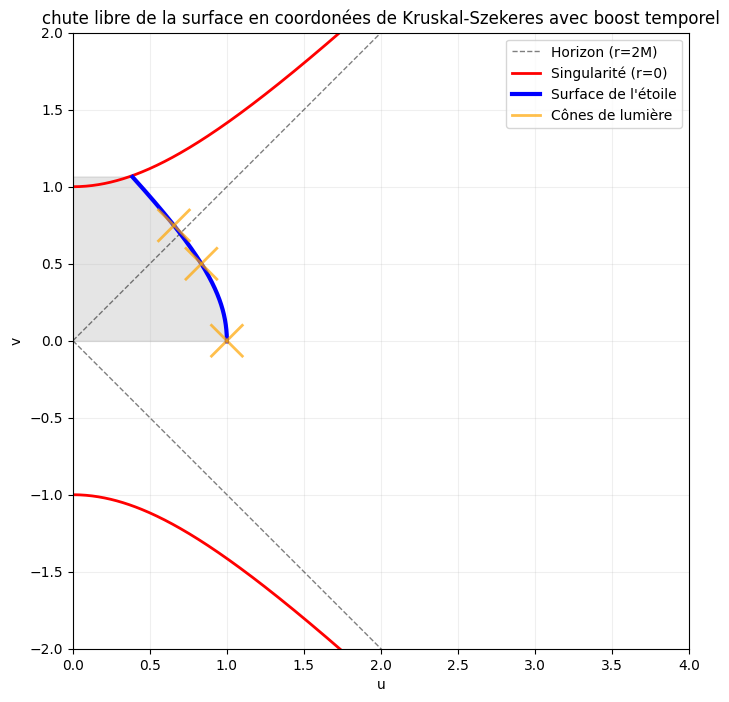

In [19]:
M = 0.5
rs = 1.0  # Rayon de Schwarzschild
Ri = 10.0 * M  # Rayon initial (5.0 dans ces unités)
dt_shift = 44 * M  # Décalage temporel spécifié dans le document

def generate_kruskal_path():
    # 1. Paramétrage cycloïdal (eta de 0 à pi)
    eta = np.linspace(0, np.pi - 0.001, 2000)
    r = (Ri / 2) * (1 + np.cos(eta))
    
    # 2. Calcul des termes de temps (MTW 31.10)
    k = np.sqrt(Ri/rs - 1)
    # Partie régulière de t/rs
    t_reg = k * (eta + (Ri/(2*rs)) * (eta + np.sin(eta)))
    
    # 3. Calcul de V+U et V-U pour éviter la divergence
    # V+U = exp((t + r*)/2rs)
    # V-U = +/- exp(-(t - r*)/2rs)
    # On gère analytiquement le produit exp(log|r-rs|) * sqrt|r-rs|
    
    # Terme de l'horizon : tan(eta/2) vaut k quand r = rs
    # On utilise la simplification : sqrt(r/rs - 1) * exp(t/2rs)
    # qui reste finie à l'horizon.
    
    # t_log = rs * ln |(k + tan)/(k - tan)|
    # r_star_log = rs * ln |r/rs - 1|
    
    # Le terme combiné (t + r*)/(2rs) sans les logs divergents :
    # On calcule l'argument de l'exponentielle de manière stable
    exp_arg_plus = (t_reg + r/rs) / 2.0
    
    # Facteur correcteur pour les logs :
    # sqrt|r/rs-1| * exp(0.5 * ln|(k+tan)/(k-tan)|)
    with np.errstate(divide='ignore', invalid='ignore'):
        term_corr = np.sqrt(np.abs(r/rs - 1)) * np.sqrt(np.abs((k + np.tan(eta/2)) / (k - np.tan(eta/2))))
    
    # Coordonnées de Kruskal de base (non boostées)
    # On multiplie par exp(r/2rs) qui vient de r*
    A = np.exp(exp_arg_plus) * term_corr * np.exp(r/(2*rs)) # C'est V+U
    B = (r/rs - 1) * np.exp(r/rs) / A # C'est V-U via la relation métrique
    
    U_base = (A - B) / 2
    V_base = (A + B) / 2
    
    # 4. Application de la translation temporelle (t -> t + 42.8M)
    # Cela correspond à une transformation de Lorentz (boost) dans le plan (U, V)
    alpha = dt_shift / (2 * rs)
    U = U_base * np.cosh(alpha) - V_base * np.sinh(alpha)
    V = V_base * np.cosh(alpha) - U_base * np.sinh(alpha)
    
    return U, V

# --- Tracé du graphique ---
U, V = generate_kruskal_path()

# Clipping de la trajectoire pour ne pas dépasser la singularité (v² - u² = 1)
singularity_distance = V**2 - U**2  # Distance à la singularité
clip_mask = singularity_distance <0.99  # Garder seulement les points avant la singularité (avec marge)
U_clipped = U[clip_mask]
V_clipped = V[clip_mask]

fig, ax = plt.subplots(figsize=(8, 8))

# Horizon (r=2M)
ax.plot([0, 5], [0, 5], 'k--', lw=1, alpha=0.5, label="Horizon (r=2M)")
ax.plot([0, 5], [0, -5], 'k--', lw=1, alpha=0.5)

# Singularité (r=0) -> V^2 - U^2 = 1
u_s = np.linspace(-5, 5, 1000)
v_s = np.sqrt(1 + u_s**2)
ax.plot(u_s, v_s, 'r', lw=2, label="Singularité (r=0)")

u_s2 = np.linspace(-5, 5, 1000)
v_s2 = -np.sqrt(1 + u_s2**2)
ax.plot(u_s2, v_s2, 'r', lw=2)


# Surface de l'étoile (courbe clippée)
ax.plot(U_clipped, V_clipped, 'b', lw=3, label="Surface de l'étoile")
ax.fill_betweenx(V_clipped, -5, U_clipped, color='gray', alpha=0.2) # Zone intérieure

# Cônes de lumière à des valeurs spécifiques de v (1.0, 0.75, 0.5)
v_targets = [ 0.75, 0.5]
cone_points = [(1, 0, 0)]  # Ajouter le point d'origine pour les cônes à l'horizon

for v_target in v_targets:
    # Trouver l'indice le plus proche de v_target
    idx = np.argmin(np.abs(V - v_target))
    if idx < len(U):
        cone_points.append((U[idx], V[idx], v_target))

# Tracer les cônes
for cone_idx, (u0, v0, v_label) in enumerate(cone_points):
    # Cône sortant (pente +1 : v = u + cste)
    u_cone_out = np.linspace(u0 - 0.1, u0 + 0.10, 100)
    v_cone_out = u_cone_out + (v0 - u0)
    
    # Cône entrant (pente -1 : v = -u + cste)
    u_cone_in = np.linspace(u0 - 0.1, u0 + 0.10, 100)
    v_cone_in = -u_cone_in + (v0 + u0)
    
    # Ajouter le label uniquement sur le premier cône
    label_str = "Cônes de lumière" if cone_idx == 0 else ""
    ax.plot(u_cone_out, v_cone_out, 'orange', lw=2, alpha=0.7, label=label_str)
    ax.plot(u_cone_in, v_cone_in, 'orange', lw=2, alpha=0.7)
    
    # Marquer le point sur la trajectoire
    ax.plot(u0, v0, color='orange', markersize=6)

# Échelles identiques à l'image (b)
ax.set_xlim(0, 4)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_title('chute libre de la surface en coordonées de Kruskal-Szekeres avec boost temporel')
ax.legend()
ax.grid(True, alpha=0.2)